In [2]:
import os
import pandas as pd

df = pd.read_csv("classified_conversations.csv")

df.head()

,conversation,intent,objections,product_category,engagement_level
0,"Customer: Hi, Im interested in purchasing a ne...",Customer is interested in purchasing a new pro...,Customer has raised objections about product f...,Electronics Product,warm
1,"Customer: Hi, Im interested in learning more a...",Customer is seeking a solution to a specific h...,Customer has raised objections about product e...,Health Product,warm
2,"Customer: Hi, Im interested in investing in th...",Customer is interested in investing in the sto...,Customer has raised objections about trust and...,Financial Service,hot
3,"Customer: Hello, Im interested in your financi...",Customer is interested in financial planning s...,"Customer has raised objections about trust, pr...",Financial Service,warm
4,"Customer: Hi, Im interested in purchasing a ne...",Customer is interested in purchasing a new pro...,Customer has raised objections about product f...,Electronics Product,warm


[Text(0, 0, '2101'), Text(0, 0, '614'), Text(0, 0, '232'), Text(0, 0, '1')]

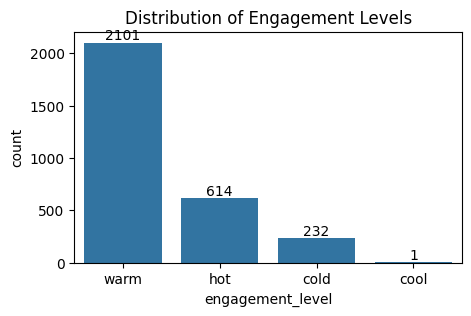

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df.value_counts("engagement_level")

plt.figure(figsize=(5, 3))
sns.countplot(x="engagement_level", data=df, order=df["engagement_level"].value_counts().index)
plt.title("Distribution of Engagement Levels")
plt.bar_label(plt.gca().containers[0])

In [12]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

mask = df["objections"].notna()
objection_embeddings = model.encode(df.loc[mask, "objections"].tolist())

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5299.15it/s]


In [14]:
import umap

reducer = umap.UMAP(n_components=5, random_state=42)
objection_umap = reducer.fit_transform(objection_embeddings)

c:\Users\xzero\Documents\Projects\sales-conversation-analysis\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
objection_umap.shape


(2854, 5)

In [29]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=25)
objections_clusters = clusterer.fit_predict(objection_umap)

In [30]:
print(len(set(objections_clusters)))

pd.Series(objections_clusters).value_counts()

10


 8    2227
 3     153
 2     116
-1      94
 0      63
 1      54
 4      42
 7      39
 6      35
 5      31
Name: count, dtype: int64

In [32]:
mask = df["objections"].notna()
df.loc[mask, "objection_cluster"] = objections_clusters

pd.set_option('display.max_colwidth', None)
df[df["objection_cluster"] == 8]["objections"].head(20)

0                                                                                                    Customer has raised objections about product features and budget
1                                                                            Customer has raised objections about product effectiveness, side effects, and skepticism
2                                                                     Customer has raised objections about trust and previous bad experiences with financial advisors
3                                                                             Customer has raised objections about trust, previous bad experiences, and affordability
4                                                                              Customer has raised objections about product features, budget, and technical expertise
5                                                                     Customer has raised objections about trust and previous bad experiences with financial advisors
6   